In [23]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Reshape, Flatten,
                                     Embedding, Concatenate, LeakyReLU,
                                     BatchNormalization, Conv2DTranspose,
                                     Conv2D, Dropout)
from tensorflow.keras.optimizers import Adam

In [24]:

(X_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

X_train = (X_train.astype('float32') - 127.5) / 127.5
X_train = X_train[..., np.newaxis]

num_classes = 10
latent_dim = 100

print("X_train shape:", X_train.shape)
print("Labels:", np.unique(y_train))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28, 1)
Labels: [0 1 2 3 4 5 6 7 8 9]


In [25]:

def build_generator(latent_dim, num_classes):
    noise = Input(shape=(latent_dim,))

    label = Input(shape=(1,))
    label_emb = Embedding(num_classes, 50)(label)
    label_emb = Flatten()(label_emb)

    x = Concatenate()([noise, label_emb])

    x = Dense(7 * 7 * 256, use_bias=False)(x)
    x = Reshape((7, 7, 256))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2DTranspose(128, (4,4), strides=2, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)

    x = Conv2DTranspose(64, (4,4), strides=2, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)
    output = Conv2DTranspose(1, (4,4), padding='same', activation='tanh')(x)

    return Model([noise, label], output, name="Generator")

generator = build_generator(latent_dim, num_classes)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 50)     │        500 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 50)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 150)       │          0 │ input_layer_10[0… │
│ (Concatenate)       │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 12544)     │  1,881,600 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 7, 7, 256) │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 256) │      1,024 │ reshape_5[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 7, 7, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 14, 14,    │    524,288 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_10 │ (None, 28, 28,    │    131,072 │ leaky_re_lu_7[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_11 │ (None, 28, 28, 1) │      1,025 │ leaky_re_lu_8[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,540,277 (9.69 MB)

 Trainable params: 2,539,381 (9.69 MB)

 Non-trainable params: 896 (3.50 KB)

In [27]:

def build_discriminator(num_classes):

    img = Input(shape=(28, 28, 1))

    label = Input(shape=(1,))
    label_emb = Embedding(num_classes, 50)(label)
    label_emb = Dense(28 * 28)(label_emb)
    label_emb = Reshape((28, 28, 1))(label_emb)

    x = Concatenate()([img, label_emb])

    x = Conv2D(64, (4,4), strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Conv2D(128, (4,4), strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Dropout(0.3)(x)

    x = Flatten()(x)
    output = Dense(1, activation='sigmoid')(x)

    return Model([img, label], output, name="Discriminator")

discriminator = build_discriminator(num_classes)
discriminator.compile(optimizer=Adam(0.0002, 0.5),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 1, 50)     │        500 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1, 784)    │     39,984 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 28, 28, 2) │          0 │ input_layer_14[0… │
│ (Concatenate)       │                   │            │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │      2,112 │ concatenate_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 14, 14,    │          0 │ conv2d_8[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 14, 14,    │          0 │ leaky_re_lu_11[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 7, 7, 128) │    131,200 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 7, 7, 128) │          0 │ conv2d_9[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 6272)      │          0 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │      6,273 │ flatten_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 180,069 (703.39 KB)

 Trainable params: 180,069 (703.39 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:

discriminator.trainable = False

noise_input = Input(shape=(latent_dim,))
label_input = Input(shape=(1,))

fake_img = generator([noise_input, label_input])
validity = discriminator([fake_img, label_input])

cgan = Model([noise_input, label_input], validity, name="cGAN")
cgan.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

print("cGAN model built successfully!")

cGAN model built successfully!


In [29]:

def train_cgan(epochs=20, batch_size=64):
    real = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))

    for epoch in range(1, epochs + 1):
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        real_imgs = X_train[idx]
        real_labels = y_train[idx].reshape(-1, 1)

        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        fake_labels = np.random.randint(0, num_classes, (batch_size, 1))
        fake_imgs = generator.predict([noise, fake_labels], verbose=0)

        d_loss_real = discriminator.train_on_batch([real_imgs, real_labels], real)
        d_loss_fake = discriminator.train_on_batch([fake_imgs, fake_labels], fake)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        gen_labels = np.random.randint(0, num_classes, (batch_size, 1))
        g_loss = cgan.train_on_batch([noise, gen_labels], real)

        print(f"Epoch {epoch}/{epochs} | D loss: {d_loss[0]:.4f} | G loss: {g_loss:.4f}")

train_cgan(epochs=20, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/20 | D loss: 0.7016 | G loss: 0.7246
Epoch 2/20 | D loss: 0.7035 | G loss: 0.7022
Epoch 3/20 | D loss: 0.7038 | G loss: 0.6863
Epoch 4/20 | D loss: 0.7036 | G loss: 0.6691
Epoch 5/20 | D loss: 0.7033 | G loss: 0.6562
Epoch 6/20 | D loss: 0.7032 | G loss: 0.6457
Epoch 7/20 | D loss: 0.7038 | G loss: 0.6373
Epoch 8/20 | D loss: 0.7046 | G loss: 0.6300
Epoch 9/20 | D loss: 0.7051 | G loss: 0.6254
Epoch 10/20 | D loss: 0.7049 | G loss: 0.6198
Epoch 11/20 | D loss: 0.7047 | G loss: 0.6146
Epoch 12/20 | D loss: 0.7046 | G loss: 0.6101
Epoch 13/20 | D loss: 0.7047 | G loss: 0.6051
Epoch 14/20 | D loss: 0.7048 | G loss: 0.6009
Epoch 15/20 | D loss: 0.7052 | G loss: 0.5970
Epoch 16/20 | D loss: 0.7054 | G loss: 0.5927
Epoch 17/20 | D loss: 0.7057 | G loss: 0.5888
Epoch 18/20 | D loss: 0.7060 | G loss: 0.5852
Epoch 19/20 | D loss: 0.7060 | G loss: 0.5813
Epoch 20/20 | D loss: 0.7061 | G loss: 0.5776


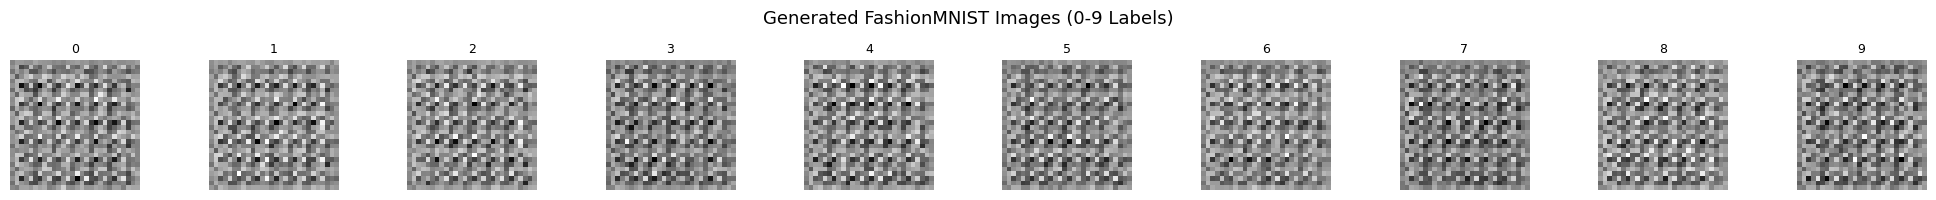

In [30]:
# Cell 7: Generate one image per class label (0–9)
def generate_by_label(generator, latent_dim, num_classes=10):
    fig, axes = plt.subplots(1, num_classes, figsize=(20, 2))
    fig.suptitle("Generated FashionMNIST Images (0-9 Labels)", fontsize=13)

    fashion_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
                     'Sandal','Shirt','Sneaker','Bag','Ankle boot']

    for label in range(num_classes):
        noise = np.random.normal(0, 1, (1, latent_dim))
        lbl = np.array([[label]])
        img = generator.predict([noise, lbl], verbose=0)[0, :, :, 0]

        axes[label].imshow(img, cmap='gray')
        axes[label].set_title(str(label), fontsize=9)
        axes[label].axis('off')

    plt.tight_layout()
    plt.savefig("generated_fashion_mnist.png", dpi=150)
    plt.show()

generate_by_label(generator, latent_dim)

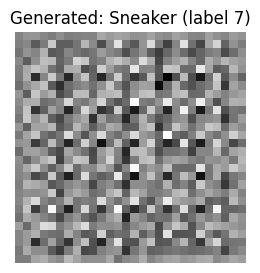

In [31]:

label_map = {
    'tshirt': 0, 'trouser': 1, 'pullover': 2, 'dress': 3,
    'coat': 4, 'sandal': 5, 'shirt': 6, 'sneaker': 7,
    'bag': 8, 'ankle boot': 9
}

def generate_from_text(text_label, generator, latent_dim):
    key = text_label.lower().strip()
    if key not in label_map:
        print(f"Unknown label '{key}'. Choose from: {list(label_map.keys())}")
        return

    label_idx = label_map[key]
    noise = np.random.normal(0, 1, (1, latent_dim))
    lbl = np.array([[label_idx]])
    img = generator.predict([noise, lbl], verbose=0)[0, :, :, 0]

    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap='gray')
    plt.title(f"Generated: {text_label.title()} (label {label_idx})")
    plt.axis('off')
    plt.show()

generate_from_text("sneaker", generator, latent_dim)